# Projekt z przedmiotu *Eksploracja Danych*

## Etap 2:  Przygotowanie danych + Modelowanie

### Analizowany zbiór danych: **Brewer's Friend Beer Recipes**

#### Autorzy:
- Anna Sztukowska 188803
- Michał Sugalski 193290
- Lucjan Gackowski 193150


#### Ogólny opis zbioru

Zbiór **Brewer's Friend Beer Recipes** zawiera dane dotyczące domowych receptur piwa udostępnianych przez użytkowników platformy Brewer's Friend – narzędzia wspierającego amatorskich i półprofesjonalnych piwowarów. Każdy wiersz odpowiada jednej recepturze i zawiera ogólne parametry techniczne związane z procesem warzenia.
Dane obejmują szeroki zakres ogólnych parametrów warzenia, takich jak styl piwa, zawartość alkoholu (`ABV`), poziom goryczki (`IBU`), kolor (`SRM`), gęstość początkowa (`OG`) i końcowa (`FG`), metoda warzenia (np. all grain, extract), objętości na różnych etapach produkcji, a także temperatury fermentacji.
Dane mają postać numeryczną lub kategoryczną i mogą służyć do analizy trendów, porównań stylów piwa, klasteryzacji receptur lub budowy modeli predykcyjnych opartych na parametrach fizykochemicznych trunku.

#### Charakterystyka zbioru danych
- **Pochodzenie:** Dane zostały zebrane z platformy Brewer's Friend i udostępnione na Kaggle przez użytkownika jtrofe.
- **Format:** `.csv`
- **Liczba przykładów:** 73 861 receptur piwa
- **Liczba atrybutów:** 23 kolumny opisujące właściwości każdej receptury
- **Struktura:** Zbiór składa się z dwóch plików:
  - `recipeData.csv` – główny zbiór zawierający informacje o recepturach piwa
  - `styleData.csv` – uzupełniający zbiór zawierający opisy stylów piwa

#### Określenie celu eksploracji i kryteriów sukcesu

Celem eksploracji jest klasyfikacja stylu piwa na podstawie jego właściwości fizykochemicznych, takich jak zawartość alkoholu `(ABV)`, goryczka `(IBU)`, gęstości `(OG, FG)`, kolor `(SRM)` oraz metoda warzenia.
Docelowo rozwiązywanym problemem jest klasyfikacja wieloklasowa, ponieważ styl piwa przyjmuje wiele możliwych wartości nominalnych.
Dodatkowym celem jest zidentyfikowanie, które cechy mają największy wpływ na klasyfikację stylu piwa — będzie to realizowane m.in. przez analizę ważności cech (feature importance).

Najbardziej istotną metryką będzie `accuracy` (dokładność klasyfikacji), czyli stosunek poprawnie sklasyfikowanych próbek do ogólnej liczby próbek. Ze względu na potencjalną nierównowagę klas (niektóre style mogą występować znacznie częściej), dodatkowo zastosowane zostaną metryki:

Jako dodatkową, pomocniczą metrykę użyjemy `Balanced accuracy` - obliczającą średnią arytmetyczną czułości (`recall`) dla każdej klasy, co zapewnia, że model jest oceniany sprawiedliwie, niezależnie od liczności poszczególnych stylów piwa. Dzięki temu unikniemy sytuacji, w której wysoka dokładność wynika wyłącznie z poprawnego klasyfikowania dominujących klas, podczas gdy rzadkie style są ignorowane.

Dodatkowo zastosowane zostaną następujące metryki:

**Macro F1-score** to średnia arytmetyczna wartości F1 obliczonych osobno dla każdej klasy. Traktuje wszystkie klasy z równą wagą, niezależnie od ich liczności. Jest to szczególnie przydatna metryka przy niezbalansowanych danych, ponieważ zapobiega faworyzowaniu dominujących klas.

Wzory:

- F1-score dla pojedynczej klasy:

  $$
  F1 = 2 \cdot \frac{\text{precyzja} \cdot \text{czułość}}{\text{precyzja} + \text{czułość}}
  $$

- Precyzja (precision):

  $$
  \text{precyzja} = \frac{TP}{TP + FP}
  $$
  gdzie:
  - TP (True Positive) – liczba przypadków poprawnie zaklasyfikowanych jako pozytywne (np. poprawnie rozpoznany styl piwa),
  - FP (False Positive) – liczba przypadków błędnie zaklasyfikowanych jako pozytywne (np. piwo przypisane do danego stylu, chociaż nim nie jest).

- Czułość (recall):

  $$
  \text{czułość} = \frac{TP}{TP + FN}
  $$

- Macro F1-score:

  $$
  \text{macro F1-score} = \frac{1}{N} \sum_{i=1}^{N} F1_i
  $$

  Gdzie \( N \) to liczba klas.

**Confusion matrix**

Macierz pomyłek (`confusion matrix`) pozwala przeanalizować, które style piwa są najczęściej mylone między sobą.

Sukces zostanie osiągnięty, jeżeli:
- model osiągnie `accuracy` powyżej 60%,
- model osiągnie `balanced accuracy` powyżej 60%,
- model osiągnie `macro F1-score` powyżej 65%.


Przy wieloklasowym problemie klasyfikacyjnym i nieidealnie zbalansowanych danych będzie to oznaczać skuteczną eksplorację stylów piwa na podstawie parametrów technicznych.

#### Dyskusja kroków dalszego postępowania



##### Dobór działania eksploracji

Zgodnie z celem eksploracji, który został zdefiniowany w Raporcie 1., dążymy do klasyfikacji stylu piwa na podstawie jego właściwości fizykochemicznych oraz identyfikacji kluczowych cech determinujących dany styl. Analiza wstępna wykazała, że atrybut `StyleID` wykazuje słabą korelację liniową z pojedynczymi cechami, co sugeruje złożony, nieliniowy charakter problemu. W związku z tym, wybrano dwuetapowe podejście algorytmiczne.

Wstępna analiza danych ujawniła trzy kluczowe wyzwania, które muszą zostać zaadresowane w dalszych krokach:

- Znaczna liczba brakujących danych w niektórych kolumnach.
- Duża liczba klas (stylów piwa), z których wiele jest niedostatecznie reprezentowanych (problem niezbalansowanych klas).
- Obecność licznych wartości odstających, które mogą zakłócać działanie algorytmów eksploracyjnych.


##### Dobór algorytmu eksploracji
1. Klasteryzacja (Grupowanie stylów piwa)

Pierwszym krokiem będzie uproszczenie problemu poprzez zastosowanie algorytmu klasteryzacji. Zamiast klasyfikować ponad 170 indywidualnych stylów, co przy niezbalansowanym zbiorze jest zadaniem niezwykle trudnym, połączymy je w mniejsze, spójne merytorycznie grupy.

- Wybrany algorytm: K-średnich (K-Means)


Algorytm K-średnich jest metodą uczenia maszynowego bez nadzoru, której celem jest podział zbioru danych na z góry określoną liczbę klastrów - w naszym przypadku 6 klastrów. Działa on iteracyjnie, grupując podobne do siebie punkty danych, minimalizując wariancję wewnątrz klastrów. W naszym projekcie zastosujemy go na kluczowych cechach fizykochemicznych (`IBU`, `ABV`, `Color`), aby zidentyfikować naturalne skupiska receptur, które dzielą podobne parametry.

Zastosowanie klasteryzacji K-średnich przed właściwą klasyfikacją przynosi kluczowe korzyści:

- Redukcja złożoności:

    Zmniejszenie liczby klas z ponad 170 do około 10-15 znacząco upraszcza zadanie klasyfikacyjne i zwiększa szansę na uzyskanie modelu o wysokiej skuteczności.

- Obsługa niezbalansowanych klas:

    Rzadkie style piwa, które mają zbyt mało próbek do efektywnego uczenia, zostaną połączone z podobnymi, liczniejszymi stylami, tworząc bardziej zrównoważone grupy.

- Zwiększenie interpretowalności:

    Grupy opisowe (np. "Lager & Pilsner" czy "Stout & Porter") są bardziej intuicyjne i użyteczne z biznesowego punktu widzenia niż pojedyncze, często bardzo niszowe style. Wyniki klasteryzacji zostaną zweryfikowane przy użyciu wiedzy domenowej, np. w oparciu o wytyczne BJCP (Beer Judge Certification Program).

<br />

2. Klasyfikacja (Predykcja grupy stylów)

Po utworzeniu grup stylów, głównym zadaniem będzie zbudowanie modelu klasyfikacyjnego, który na podstawie cech receptury przypisze ją do odpowiedniej grupy.

- Wybrany algorytm: Las Losowy (Random Forest Classifier)


Las Losowy to zaawansowana technika uczenia zespołowego, która buduje wiele drzew decyzyjnych w procesie treningu, a ostateczną predykcję podejmuje na podstawie "głosowania" większości z nich. Jest to jeden z najskuteczniejszych i najbardziej uniwersalnych algorytmów klasyfikacyjnych.

Random Forest jest idealnym wyborem dla naszego problemu z kilku powodów:

- Wysoka skuteczność i odporność na przeuczenie: Dzięki agregacji wyników z wielu drzew, algorytm jest znacznie bardziej stabilny i dokładny niż pojedyncze drzewo decyzyjne, jednocześnie minimalizując ryzyko przeuczenia.

- Zdolność do modelowania nieliniowych zależności: Jak wskazano w Raporcie 1, proste zależności liniowe nie wystarczają do opisania stylu piwa. Lasy Losowe doskonale radzą sobie z wychwytywaniem złożonych interakcji między wieloma cechami.

- Wbudowana analiza ważności cech: Algorytm w naturalny sposób dostarcza miarę ważności każdej cechy (feature importance), co bezpośrednio realizuje nasz dodatkowy cel, jakim jest identyfikacja najważniejszych parametrów wpływających na styl piwa.

- Odporność na wartości odstające i skalowanie danych: Lasy Losowe są mniej wrażliwe na outliery, których obecność stwierdzono w Raporcie 1, i nie wymagają skomplikowanego skalowania cech.

<br />

Połączenie nienadzorowanej klasteryzacji K-średnich z nadzorowaną klasyfikacją za pomocą Lasu Losowego stanowi solidną i kompleksową strategię, która adresuje kluczowe wyzwania zidentyfikowane w naszym zbiorze danych.


##### Dobór metody testowania wyników

#### Przygotowanie danych



##### !!!!!!!!!!!Dane brakujące i dane do ujednolicenia

Kluczowe statystyki braków (na podstawie pierwszego raportu):

|    Kolumna    | Braki | % Braków |  Decyzja |
|:-------------:|:-----:|:--------:|:--------:|
| PrimingMethod | 67101 | 90.8%    | Usunąć   |
| PrimingAmount | 69087 | 93.5%    | Usunąć   |
| PitchRate     | 39252 | 53.1%    | Usunąć   |
| MashThickness | 29864 | 40.4%    | Usunąć wybrane wiersze |
| PrimaryTemp   | 22662 | 30.7%    | Usunąć wybrane wiersze |
| BoilGravity   | 2990  | 4.0%     | Usunąć wybrane wiersze |

Uzasadnienie decyzji:
- Kolumny z >50% braków usuwane ze względu na niemożność wiarygodnej imputacji
- `MashThickness`, `PrimaryTemp` i `BoilGravity` pozostają zachowane pomimo znaczących braków - w zależności od dalszej analizy mogą być istotne dla klasyfikacji stylu piwa, a ich brak można będzie uzupełnić metodami imputacji (np. średnią, medianą lub regresją), lub później usunąć, jeśli metody imputacji nie okażą się wystarczająco wiarygodne.





##### Zamiana na nominalne/numeryczne

W naszym zbiorze danych zidentyfikowano dwie kluczowe kolumny nominalne, które wymagają konwersji: `SugarScale` oraz `BrewMethod`.

Do ich transformacji zostanie zastosowana technika kodowania etykietami (Label Encoding) poprzez zdefiniowane mapowania.

Atrybut `SugarScale`:
   - `Specific Gravity` zostanie zakodowane jako 0
   - `Plato` zostanie zakodowane jako 1

Atrybut `BrewMethod`:
   - `All Grain` zostanie zakodowane jako 0.
   - `extract` zostanie zakodowane jako 1.
   - `Partial Mash` zostanie zakodowane jako 2.
   - `BIAB` zostanie zakodowane jako 3

Dla algorytmów opartych na drzewach decyzyjnych, takich jak wybrany w naszym projekcie Las Losowy, proste kodowanie etykietami jest wystarczające i akceptowalne.

##### Podzbiór danych
Z oryginalnego zbioru danych zostały całkowicie usunięte kolumny `PrimingMethod`, `PrimingAmount` oraz `PitchRate` ze względu na dużą ilość brakujących wartości. Następnie usunięte zostały wiersze, które nie zawierały wartości w jakiejkolwiek z pozostałych "wybrakowanych" kolumn (`MashThickness`, `PrimaryTemp`, `BoilGravity`). Przed wykorzystaniem modelu klasyfikującego tak oczyszczony podzbiór podzielony został na dwa kolejne: treningowy i testowy mające odpowiednio 25178 i 6295 wierszy.

##### Uzupełnienie danych
*Brak*


Przeanalizowaliśmy zachowanie modelu klasyfikującego w przypadku zastosowania różnych metod uzupełniania danych. Początkowo brakujące wartości próbowaliśmy wypełniać medianami atrybutów, natomiast nie poprawiło to jakości modelu. Podjęta została próba zastosowania regresji (liniowej i lasu losowego) w celu uzupełnienia braków, ale również w żadnym stopniu nie wpłynęła na dokładność klasyfikacji.


#### Utworzenie modelu - Ręczne Grupowanie i Klasyfikacja - Michal

#### Utworzenie modelu - Klasteryzacja i Klasyfikacja - Ania

W ramach analizy danych przeprowadzono proces modelowania składający się z dwóch głównych etapów: klasteryzacji przy użyciu algorytmu K-średnich oraz klasyfikacji z wykorzystaniem Random Forest.

Etap klasteryzacji rozpoczęto od przygotowania danych, usuwając rekordy z brakującymi wartościami i standaryzując wybrane 14 cech charakterystycznych piw, w tym takie parametry jak ekstrakt początkowy (`OG`), ekstrakt końcowy (`FG`), zawartość alkoholu (`ABV`), goryczka (`IBU`) czy kolor (`Color`). Algorytm K-średnich uruchomiono z domyślnymi parametrami, ustalając liczbę klastrów na 6 oraz ziarno losowości 42 dla zapewnienia powtarzalności wyników. W wyniku działania algorytmu każdemu piwu przypisano przynależność do jednego z klastrów:







Wykresy przedstawiające poszczególne średnie wartości atrybutów `Color`, `IBU` oraz `ABV` w każdym z klastrów.

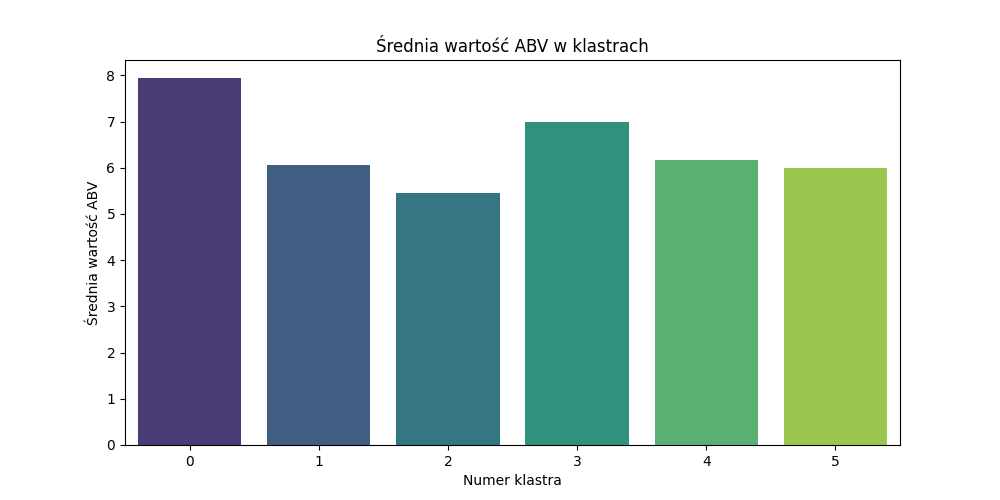

![klaster_color.png](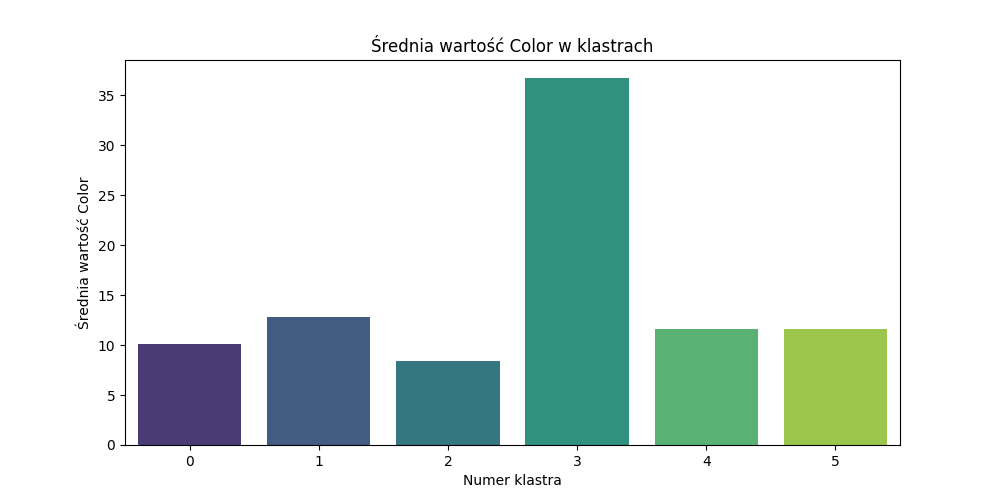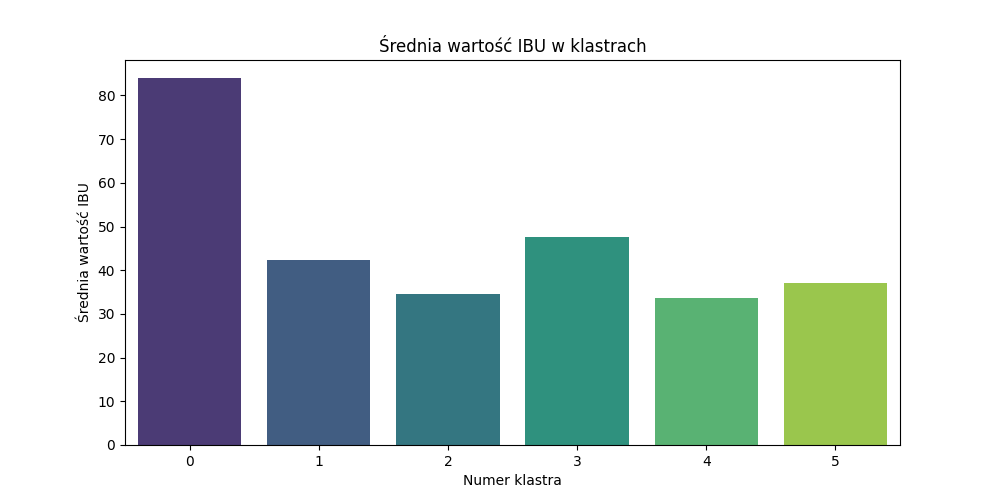)

#### Eksperymenty z modelem i zbiorem danych - Lucjan

W celu znalezienia optymalnego modelu predykcyjnego przeprowadziliśmy serię eksperymentów, których głównym celem było porównanie skuteczności różnych algorytmów klasyfikacyjnych w połączeniu z wieloma strategiami obsługi brakujących danych. Jak zidentyfikowano w Raporcie 1, istotnym wyzwaniem w naszym zbiorze jest duża liczba braków w kluczowych kolumnach, co wymagało dogłębnej analizy wpływu różnych metod ich uzupełniania na finalną jakość predykcji.

Nasze eksperymenty skupiły się na systematycznym testowaniu następujących scenariuszy:

1. Porównanie strategii obsługi brakujących danych

Badaliśmy szerokie spektrum podejść, od najprostszych po zaawansowane techniki imputacji, aby ocenić, która z nich najlepiej zachowuje wartość informacyjną zbioru danych. Testowane metody to:

- `dropna` (usunięcie wierszy): Najbardziej rygorystyczne podejście, polegające na całkowitym usunięciu każdego rekordu zawierającego choćby jedną brakującą wartość.

- `simple_mean / simple_median` (imputacja statystyczna): Uzupełnienie braków średnią arytmetyczną lub medianą z danej kolumny.

- `knn` (imputacja metodą k-najbliższych sąsiadów): Wypełnienie brakującej wartości na podstawie wartości od k najbardziej podobnych rekordów w zbiorze.

- `iterative` (imputacja iteracyjna): Zaawansowana technika oparta na regresji (podobna do MICE), gdzie każda cecha z brakami jest modelowana jako funkcja pozostałych cech, a proces jest powtarzany iteracyjnie aż do uzyskania stabilnych wyników.

2. Porównanie algorytmów klasyfikacyjnych

Dla każdej z powyższych strategii przygotowania danych przetestowano szereg modeli klasyfikujących, aby sprawdzić, który z nich najlepiej radzi sobie ze specyfiką naszego problemu:

Modele zespołowe oparte na drzewach:
- `Random Forest`
- `Gradient Boosting`
- `HistGradientBoosting`

Klasyczne modele statystyczne:
- Regresja Logistyczna

Inne popularne algorytmy:
- Maszyny Wektorów Nośnych `(SVC)`
- k-Najbliższych Sąsiadów `(KNN)`,
- Pojedyncze Drzewo Decyzyjne oraz Naiwny Klasyfikator Bayesowski.

Wnioski z przeprowadzonych eksperymentów
Analiza wyników, zebranych w postaci metryk accuracy i macro F1-score, doprowadziła do kilku kluczowych i momentami zaskakujących spostrzeżeń:

Najlepsza strategia: Usunięcie brakujących danych `(dropna)`

Najwyższą skuteczność we wszystkich przeprowadzonych testach osiągnął model Random Forest wytrenowany na zbiorze danych, z którego po prostu usunięto wszystkie wiersze z brakującymi wartościami. Ta kombinacja uzyskała accuracy na poziomie `0.612` oraz F1-score równe `0.589`.

Wyniki przeprowadzonych eksperymentów:

| Metoda imputacji | Klasyfikator         | Accuracy | F1-score  |
|------------------|----------------------|----------|-----------|
|      dropna      |     RandomForest     | 0.612073 | 0.589128  |
| dropna           | GradientBoosting     | 0.597458 | 0.580891  |
| dropna           | HistGradientBoosting | 0.589833 | 0.570572  |
| simple_mean      | RandomForest         | 0.579062 | 0.551581  |
| knn              | RandomForest         | 0.578380 | 0.550524  |
| iterative        | RandomForest         | 0.577220 | 0.548768  |
| simple_mean      | GradientBoosting     | 0.574763 | 0.550711  |
| simple_median    | RandomForest         | 0.574490 | 0.547327  |
| dropna           | SVC                  | 0.573948 | 0.539541  |
| iterative        | GradientBoosting     | 0.573944 | 0.549718  |
| simple_median    | GradientBoosting     | 0.573807 | 0.549866  |
| knn              | GradientBoosting     | 0.571419 | 0.546873  |
| simple_mean      | HistGradientBoosting | 0.563844 | 0.536922  |
| simple_median    | HistGradientBoosting | 0.562137 | 0.536104  |
| iterative        | HistGradientBoosting | 0.560363 | 0.532690  |
| knn              | HistGradientBoosting | 0.557906 | 0.531369  |
| dropna           | LogisticRegression   | 0.540270 | 0.487471  |
| simple_median    | SVC                  | 0.536477 | 0.500335  |
| knn              | SVC                  | 0.534976 | 0.497670  |
| dropna           | KNN                  | 0.534710 | 0.517284  |
| iterative        | SVC                  | 0.534362 | 0.497116  |
| simple_mean      | SVC                  | 0.533816 | 0.496576  |
| simple_median    | KNN                  | 0.497782 | 0.478287  |
| knn              | KNN                  | 0.496758 | 0.476844  |
| iterative        | KNN                  | 0.496212 | 0.476507  |
| simple_mean      | KNN                  | 0.495189 | 0.475178  |
| knn              | LogisticRegression   | 0.485498 | 0.424022ś |
| iterative        | LogisticRegression   | 0.484747 | 0.424154  |
| simple_mean      | LogisticRegression   | 0.484542 | 0.424173  |
| simple_median    | LogisticRegression   | 0.481676 | 0.421160  |
| dropna           | DecisionTree         | 0.470850 | 0.472954  |
| simple_mean      | DecisionTree         | 0.437726 | 0.440390  |
| iterative        | DecisionTree         | 0.435201 | 0.438343  |
| simple_median    | DecisionTree         | 0.434109 | 0.436659  |
| knn              | DecisionTree         | 0.427353 | 0.431013  |
| simple_mean      | NaiveBayes           | 0.220023 | 0.263998  |
| knn              | NaiveBayes           | 0.210469 | 0.256586  |
| iterative        | NaiveBayes           | 0.204190 | 0.251684  |
| simple_median    | NaiveBayes           | 0.194499 | 0.246099  |
| dropna           | NaiveBayes           | 0.089913 | 0.114198  |



#### Podsumowanie wyników




